In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
from constants import *
import IPython.display as ipd
import matplotlib.pyplot as plt
from utils import stitch_wave_chunks
from dataset import train_data_loader, test_data_loader

In [2]:
x, y, fp_x, fp_y = next(iter(test_data_loader))
print(torch.min(x), torch.max(x))
print("Original shape:", x.shape)
# encoder
print("Encoder:")
x = nn.Conv1d(1, 16, 3, stride=2)(x)
print("1", x.shape)
x = nn.Conv1d(16, 32, 3, stride=2)(x)
print("2", x.shape)
x = nn.Conv1d(32, 64, 3, stride=2)(x)
print("3", x.shape)
x = nn.Conv1d(64, 128, 3, stride=2)(x)
print("4", x.shape)
# decoder
print("Decoder:")
x = nn.ConvTranspose1d(128, 64, 3, stride=2)(x)
print("5", x.shape)
x = nn.ConvTranspose1d(64, 32, 3, stride=2)(x)
print("6", x.shape)
x = nn.ConvTranspose1d(32, 16, 3, stride=2)(x)
print("7", x.shape)
x = nn.ConvTranspose1d(16, 1, 4, stride=2)(x)
print("8", x.shape)

tensor(0.1900) tensor(0.8629)
Original shape: torch.Size([8, 1, 9600])
Encoder:
1 torch.Size([8, 16, 4799])
2 torch.Size([8, 32, 2399])
3 torch.Size([8, 64, 1199])
4 torch.Size([8, 128, 599])
Decoder:
5 torch.Size([8, 64, 1199])
6 torch.Size([8, 32, 2399])
7 torch.Size([8, 16, 4799])
8 torch.Size([8, 1, 9600])


In [3]:
class Gtr_2_Ney_AutoEncoder_Conv(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, 3, stride=1),
            nn.ReLU(),
            nn.Conv1d(16, 32, 3, stride=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, 3, stride=1),
            nn.ReLU(),
            nn.Conv1d(64, 128, 3, stride=1)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, 3, stride=1),
            nn.ReLU(),
            nn.ConvTranspose1d(64, 32, 3, stride=1),
            nn.ReLU(),
            nn.ConvTranspose1d(32, 16, 3, stride=1),
            nn.ReLU(),
            nn.ConvTranspose1d(16, 1, 3, stride=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [4]:
gtr_2_ney_model_conv = Gtr_2_Ney_AutoEncoder_Conv()
criterion = nn.MSELoss()
optimizer = optim.Adam(gtr_2_ney_model_conv.parameters(), lr=0.001)

for epoch in range(5):
    running_loss = 0.0
    for gtr_features, ney_features, _, _ in train_data_loader:
        y_hat = gtr_2_ney_model_conv(gtr_features)
        loss = criterion(y_hat, ney_features)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch: {epoch + 1}, Loss: {running_loss:.4f}")

Epoch: 1, Loss: 1.1541
Epoch: 2, Loss: 1.0759
Epoch: 3, Loss: 0.9941
Epoch: 4, Loss: 0.9266
Epoch: 5, Loss: 0.9253
Epoch: 6, Loss: 0.9196
Epoch: 7, Loss: 0.9178
Epoch: 8, Loss: 0.9200
Epoch: 9, Loss: 0.9176
Epoch: 10, Loss: 0.9204


In [5]:
x, y, x_paths, y_paths = next(iter(test_data_loader))
print(x_paths)
print(y_paths)
predicted_chunks = None
with torch.no_grad():
    predicted_chunks = gtr_2_ney_model_conv(x).numpy()
    print(predicted_chunks.shape)
predicted_chunks = (np.squeeze(predicted_chunks, axis=1) * 2) - 1
target_chunks = np.squeeze(y.numpy(), axis=1)

stitched_wave_prediction = stitch_wave_chunks(predicted_chunks)
print("Prediction length:", len(stitched_wave_prediction))
stitched_wave_target = stitch_wave_chunks(target_chunks)
print("Target length:", len(stitched_wave_target))

('dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_0', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_1', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_2', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_3', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_4', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_5', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_6', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_7')
('dataset/features/ney/08_Ney_G_S_3/chunk_0', 'dataset/features/ney/08_Ney_G_S_3/chunk_1', 'dataset/features/ney/08_Ney_G_S_3/chunk_2', 'dataset/features/ney/08_Ney_G_S_3/chunk_3', 'dataset/features/ney/08_Ney_G_S_3/chunk_4', 'dataset/features/ney/08_Ney_G_S_3/chunk_5', 'dataset/features/ney/08_Ney_G_S_3/chunk_6', 'dataset/features/ney/08_Ney_G_S_3/chunk_7')
(8, 1, 9600)
Prediction length: 76100
Target length: 76100


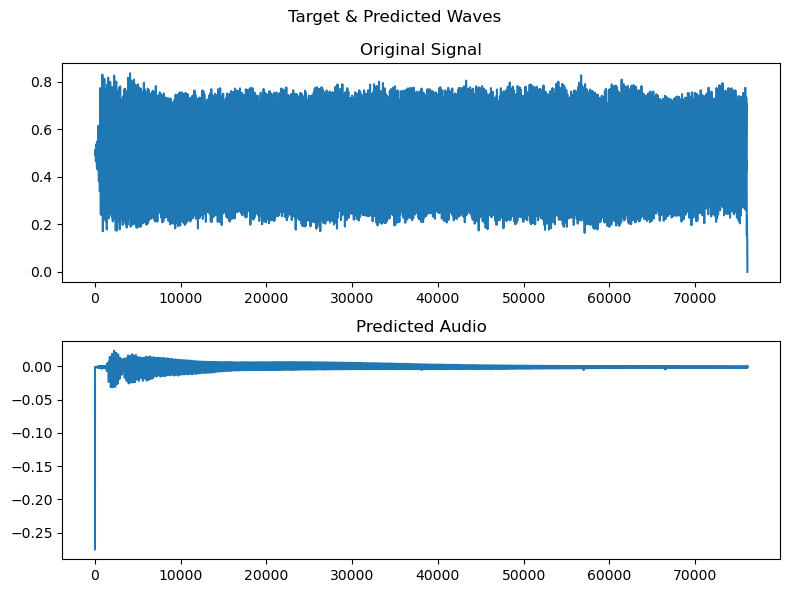

In [6]:
fig, axs = plt.subplots(2, figsize=(8, 6))
fig.suptitle("Target & Predicted Waves")
axs[0].set_title("Original Signal")
axs[0].plot(stitched_wave_target)
axs[1].set_title("Predicted Audio")
axs[1].plot(stitched_wave_prediction)
fig.tight_layout()
plt.show()

In [21]:
ipd.Audio(stitched_wave_prediction, rate=SR)

In [47]:
x, y, _, _ = next(iter(train_data_loader))
print("Original shape:", x.shape)
print("Encoder:")
x = nn.Linear(WINDOW_SAMPLE_LEN, WINDOW_SAMPLE_LEN // 2)(x)
print("1", x.shape)
x = nn.Linear(WINDOW_SAMPLE_LEN // 2, WINDOW_SAMPLE_LEN // 4)(x)
print("2", x.shape)
x = nn.Linear(WINDOW_SAMPLE_LEN // 4, WINDOW_SAMPLE_LEN // 8)(x)
print("3", x.shape)
x = nn.Linear(WINDOW_SAMPLE_LEN // 8, WINDOW_SAMPLE_LEN // 16)(x)
print("4", x.shape)

print("Decoder:")
x = nn.Linear(WINDOW_SAMPLE_LEN // 16, WINDOW_SAMPLE_LEN // 8)(x)
print("5", x.shape)
x = nn.Linear(WINDOW_SAMPLE_LEN // 8, WINDOW_SAMPLE_LEN // 4)(x)
print("6", x.shape)
x = nn.Linear(WINDOW_SAMPLE_LEN // 4, WINDOW_SAMPLE_LEN // 2)(x)
print("7", x.shape)
x = nn.Linear(WINDOW_SAMPLE_LEN // 2, WINDOW_SAMPLE_LEN)(x)
print("8", x.shape)

Original shape: torch.Size([8, 1, 9600])
Encoder:
1 torch.Size([8, 1, 4800])
2 torch.Size([8, 1, 2400])
3 torch.Size([8, 1, 1200])
4 torch.Size([8, 1, 600])
Decoder:
5 torch.Size([8, 1, 1200])
6 torch.Size([8, 1, 2400])
7 torch.Size([8, 1, 4800])
8 torch.Size([8, 1, 9600])


In [8]:
class Gtr_2_Ney_AutoEncoder_Dense(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(WINDOW_SAMPLE_LEN, WINDOW_SAMPLE_LEN // 2),
            nn.ReLU(),
            nn.Linear(WINDOW_SAMPLE_LEN // 2, WINDOW_SAMPLE_LEN // 4),
            nn.ReLU(),
            nn.Linear(WINDOW_SAMPLE_LEN // 4, WINDOW_SAMPLE_LEN // 8),
            nn.ReLU(),
            nn.Linear(WINDOW_SAMPLE_LEN // 8, WINDOW_SAMPLE_LEN // 16)
        )

        self.decoder = nn.Sequential(
            nn.Linear(WINDOW_SAMPLE_LEN // 16, WINDOW_SAMPLE_LEN // 8),
            nn.ReLU(),
            nn.Linear(WINDOW_SAMPLE_LEN // 8, WINDOW_SAMPLE_LEN // 4),
            nn.ReLU(),
            nn.Linear(WINDOW_SAMPLE_LEN // 4, WINDOW_SAMPLE_LEN // 2),
            nn.ReLU(),
            nn.Linear(WINDOW_SAMPLE_LEN // 2, WINDOW_SAMPLE_LEN),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [9]:
gtr_2_ney_model_dense = Gtr_2_Ney_AutoEncoder_Dense()
criterion = nn.MSELoss()
optimizer = optim.Adam(gtr_2_ney_model_dense.parameters(), lr=0.001)

for epoch in range(5):
    running_loss = 0.
    for gtr_features, ney_features, _, _ in train_data_loader:
        y_hat = gtr_2_ney_model_dense(gtr_features)
        loss = criterion(y_hat, ney_features)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch: {epoch + 1}, Loss: {running_loss:.4f}")

Epoch: 1, Loss: 1.0920
Epoch: 2, Loss: 1.0884
Epoch: 3, Loss: 0.9619
Epoch: 4, Loss: 0.9294
Epoch: 5, Loss: 0.9211


In [10]:
x, y, x_paths, y_paths = next(iter(test_data_loader))
print(x_paths)
print(y_paths)
predicted_chunks = None
with torch.no_grad():
    predicted_chunks = gtr_2_ney_model_dense(x).numpy()

predicted_chunks = (np.squeeze(predicted_chunks, axis=1) * 2) - 1
target_chunks = (np.squeeze(y.numpy(), axis=1) * 2) - 1

stitched_wave_prediction = stitch_wave_chunks(predicted_chunks)
print("Prediction length:", len(stitched_wave_prediction))
stitched_wave_target = stitch_wave_chunks(target_chunks)
print("Target length:", len(stitched_wave_target))

('dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_0', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_1', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_2', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_3', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_4', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_5', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_6', 'dataset/features/ac_gtr/08_Gtr_G_S_3/chunk_7')
('dataset/features/ney/08_Ney_G_S_3/chunk_0', 'dataset/features/ney/08_Ney_G_S_3/chunk_1', 'dataset/features/ney/08_Ney_G_S_3/chunk_2', 'dataset/features/ney/08_Ney_G_S_3/chunk_3', 'dataset/features/ney/08_Ney_G_S_3/chunk_4', 'dataset/features/ney/08_Ney_G_S_3/chunk_5', 'dataset/features/ney/08_Ney_G_S_3/chunk_6', 'dataset/features/ney/08_Ney_G_S_3/chunk_7')
Prediction length: 76100
Target length: 76100


In [11]:
ipd.Audio(stitched_wave_prediction, rate=SR)

In [12]:
ipd.Audio(stitched_wave_target, rate=SR)

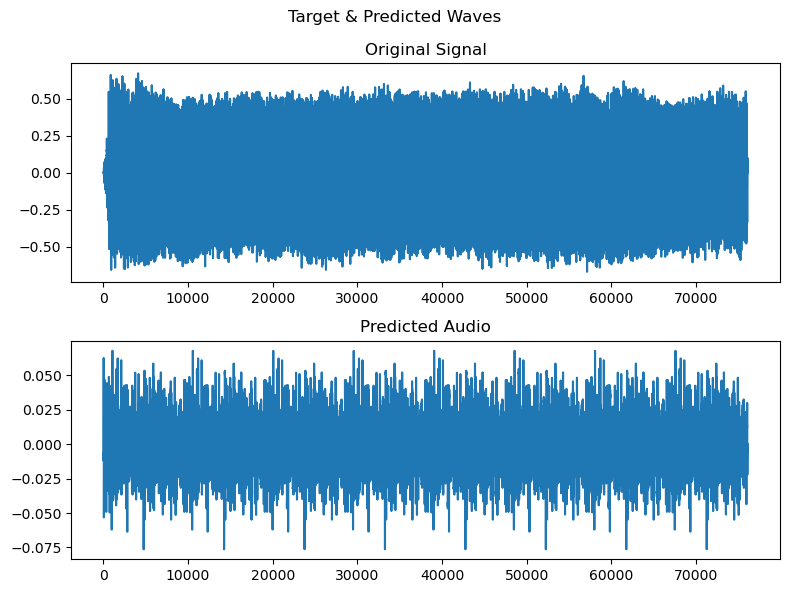

In [13]:
fig, axs = plt.subplots(2, figsize=(8, 6))
fig.suptitle("Target & Predicted Waves")
axs[0].set_title("Original Signal")
axs[0].plot(stitched_wave_target)
axs[1].set_title("Predicted Audio")
axs[1].plot(stitched_wave_prediction)
fig.tight_layout()
plt.show()